# get micro evidence prompt Test

In [1]:
# 환경 설정
import sys
import os
from pathlib import Path

# 프로젝트 루트 (notebook/ 또는 notebook/Prompts Test/ 실행 지원)
current_dir = Path.cwd()
if current_dir.name == "notebook":
    project_root = current_dir.parent
elif current_dir.parent.name == "notebook":
    project_root = current_dir.parent.parent
else:
    project_root = current_dir
sys.path.insert(0, str(project_root))

from dotenv import load_dotenv
load_dotenv(project_root / ".env")

import config
from src.utils import crop_roi_from_box
from src.utils.image_processing import slice_image
from src.models.hotspot_models import HotspotDetectionResult
from src.tools.experts.expert_utils import save_bytes_to_temp_file
from src.utils.logging_config import setup_logger

logger = setup_logger(__name__)

print(f"✓ 프로젝트 루트: {project_root}")
logger.info("프로젝트 루트 설정 완료")

✓ 프로젝트 루트: c:\Users\loidn\Documents\Projects\P_04_Scope
2026-02-07 21:32:29 [INFO] __main__.<module>: 프로젝트 루트 설정 완료


In [2]:
# ========== 프롬프트 템플릿 (여기를 직접 수정하여 테스트) ==========
# ※ src/prompts/common_prompts.py와 독립적으로 수정 가능
prompt = """
<role>
당신은 냉철하고 객관적인 **'법과학 영상 분석가(Forensic Image Analyst)'**입니다.
이미지 픽셀을 분석하는 기계적 시스템으로, 시각적 패턴만 탐지합니다.
</role>

<input_data>
**Image**: 분석 대상 영역 (1024x1024px 패치)
</input_data>

<task>
당신의 목표는 이미지 내의 시각적 팩트만을 나열하고, 그것이 화재로 인한 것인지 논리적으로 검증하는 것입니다.
절대 추측하지 마십시오. 명확한 시각적 증거(Visual Evidence)가 없다면 '식별 불가'로 판단해야 합니다.
</task>

<rules>
- 관찰 우선: Step 1~3를 거쳐 검증된 사실만 Step 4에서 출력합니다.
- 원인 추론 금지: "단락흔이다", "화재다"라고 쓰지 말고 "구형 물체다", "검게 변했다"라고 쓰십시오.
- 좌표 포맷: box_2d는 이미지 전체 크기를 1000으로 보았을 때의 정규화 좌표(0~1000 정수)를 사용합니다.(ymax > ymin, xmax > xmin)
- 빈 결과 허용: 손상이 확실하지 않으면 `hotspots` 배열을 비워서 반환하십시오.
</rules>

<analysis_process>

Step 1: 객체 영역 스캔 (Object Scanning)
- 이미지에 존재하는 주요 객체(전선, 피복, 금속 부품 등)의 경계를 파악하십시오.

Step 2: 형상 이탈 감지(Deviation Detection)
- 정상적인 형상 기준에서 벗어난 모든 부분을 포착하십시오.
  1. 비드/망울 형성(Bead Formation): 전선 끝단이나 중간에 형성된 '구형(Spherical)' 또는 '타원형' 뭉침 현상.
  2. 질량 손실(Material Loss): 피복이 사라짐, 도체가 얇아짐, 구멍 뚫림.
  3. 형태 왜곡(Distortion): 뭉침(Globular), 꺾임, 부풀어 오름, 표면 거칠어짐.
  4. 색상/질감 변화(Discoloration): 검게 변함, 광택 소실 (단, 단순 그림자는 제외).

Step 3: 형상 검증 (Reality Check)
- 감지된 이탈이 '실제 물리적 변형'인지, '착시/노이즈'인지 검증하십시오.

Step 4: 최종 손상 추출 (Final Extraction)
- - 검증을 통과한 영역만 좌표와 함께 추출하고 심각도 점수를 부여하십시오.
-형태학적 기준 (severity_score)
  - 0: 식별 불가
  - 1-30 (경미): 표면의 단순 그을음 부착, 미세한 변색 (형태 변화 없음)
  - 31-60 (중등): 형상의 열 변형, 부분적 소실, 표면이 거칠어짐, 광택 소실
  - 61-80 (심각): 형상의  완전 소실, 심한 산화 및 박리, 변색(붉은색, 푸른색 등)
  - 81-100 (치명적): 비드, 망울 등 용융 흔적이 명확히 관찰

</analysis_process>

<output_format>
결과는 반드시 아래 JSON 형식으로만 반환하십시오. Markdown이나 추가 설명을 붙이지 마십시오.

{
  "hotspots": [
    {
      "id": 1,
      "visual_evidence": "중앙 하단에 직경 2mm 추정의 매끄러운 구형 비드 식별됨. 표면 광택이 뚜렷함.",
      "severity_score": 95,
      "location_description": "패치 중앙 하단",
      "box_2d": {"ymin": 100, "xmin": 200, "ymax": 150, "xmax": 250}
    }
  ],
  "total_count": 1
}
</output_format>
"""

In [3]:
# 테스트 케이스: (category, image_path) 리스트
data_dir = project_root / "data"
image_files = list(data_dir.glob("*.jpg")) + list(data_dir.glob("*.JPG")) + list(data_dir.glob("*.png"))

test_cases = [
     {"category": "IMG_8113", "image_path": str(project_root / "data" / "IMG_8113.jpg")}
]

if not test_cases:
    raise FileNotFoundError("data/ 폴더에 이미지가 없습니다.")

logger.info(f"테스트 케이스 {len(test_cases)}개 로드")
for c in test_cases:
    logger.debug(f"  케이스: {c['category']} -> {c['image_path']}")
print(f"테스트 케이스 {len(test_cases)}개:")
for c in test_cases:
    print(f"  - {c['category']}")

2026-02-07 21:32:29 [INFO] __main__.<module>: 테스트 케이스 1개 로드
테스트 케이스 1개:
  - IMG_8113


In [4]:
# Gemini API 호출 및 결과 수집
import pandas as pd
from google import genai
from google.genai import types

def run_prompt_test(test_cases):
    api_key = os.environ.get("GEMINI_API_KEY")
    if not api_key:
        raise ValueError("GEMINI_API_KEY 환경 변수를 설정하세요.")

    client = genai.Client(api_key=api_key)
    model_name = os.environ.get("GEMINI_MODEL_NAME", config.GEMINI_MODEL_NAME)
    logger.info(f"run_prompt_test: 모델={model_name}, 케이스 수={len(test_cases)}")

    results = []
    for i, case in enumerate(test_cases):
        logger.info(f"[{i+1}/{len(test_cases)}] {case['category']} 테스트 시작")
        print(f"[{i+1}/{len(test_cases)}] {case['category']} 테스트 중...")
        try:
            # 이미지 → 첫 번째 패치만 사용 (실제 Hotspot Detector와 동일). 여러 패치로 나누지 않고 1개만 API 호출.
            patches = slice_image(case["image_path"], patch_size=1024, overlap=200)
            num_patches = len(patches) if patches else 0
            logger.info(f"{case['category']}: slice_image 패치 {num_patches}개 생성 → 첫 번째 패치만 사용 (나머지 {max(0, num_patches - 1)}개 미사용)")
            if not patches:
                logger.warning(f"{case['category']}: 패치 생성 실패")
                results.append({
                    "Category": case["category"],
                    "Input": case["image_path"],
                    "Output": "패치 생성 실패",
                    "Status": "Error",
                    "patch_path": None,
                    "hotspots": []
                })
                continue

            patch = patches[0]
            patch_path = save_bytes_to_temp_file(patch["image_bytes"])
            logger.debug(f"첫 패치 저장: {patch_path}")
            image_part = types.Part.from_bytes(data=patch["image_bytes"], mime_type="image/jpeg")

            json_schema = HotspotDetectionResult.model_json_schema()
            req = json_schema.setdefault("required", [])
            if "hotspots" not in req:
                req.append("hotspots")

            resp = client.models.generate_content(
                model=model_name,
                contents=[prompt, image_part],
                config={
                    "response_mime_type": "application/json",
                    "response_json_schema": json_schema
                }
            )
            text = getattr(resp, "text", None) or ""
            parsed = HotspotDetectionResult.model_validate_json(text)

            # 요약: 개수 + visual_evidence 요약 (Hotspot 스키마에는 damage_type 없음). 개수는 API가 반환한 값이며 코드에서 3으로 제한하지 않음.
            hs = parsed.hotspots or []
            logger.info(f"{case['category']}: API 응답 파싱 완료, hotspots={len(hs)}개 (API 반환값 그대로, 상한 없음)")
            if hs:
                for h in hs[:3]:
                    logger.debug(f"  hotspot id={h.id} severity={h.severity_score} loc={getattr(h, 'location_description', '')[:30]}")
            summary = f"{len(hs)}개 탐지"
            if hs:
                types_str = ", ".join(f"sev={h.severity_score}" for h in hs[:5])
                if len(hs) > 5:
                    types_str += f" ...외 {len(hs)-5}개"
                summary += f": {types_str}"

            results.append({
                "Category": case["category"],
                "Input": case["image_path"],
                "Output": summary,
                "Status": "Success",
                "patch_path": patch_path,
                "hotspots": [h.model_dump(mode="json") for h in hs]
            })
        except Exception as e:
            logger.error(f"{case['category']}: 오류 - {e}", exc_info=True)
            results.append({
                "Category": case["category"],
                "Input": case["image_path"],
                "Output": str(e),
                "Status": "Error",
                "patch_path": None,
                "hotspots": []
            })

    logger.info(f"run_prompt_test 완료: 성공 {sum(1 for r in results if r.get('Status') == 'Success')}/{len(results)}")
    return pd.DataFrame(results)

df_results = run_prompt_test(test_cases)

2026-02-07 21:32:30 [INFO] __main__.run_prompt_test: run_prompt_test: 모델=gemini-3-flash-preview, 케이스 수=1
2026-02-07 21:32:30 [INFO] __main__.run_prompt_test: [1/1] IMG_8113 테스트 시작
[1/1] IMG_8113 테스트 중...
2026-02-07 21:32:30 [INFO] __main__.run_prompt_test: IMG_8113: slice_image 패치 4개 생성 → 첫 번째 패치만 사용 (나머지 3개 미사용)
2026-02-07 21:32:43 [INFO] __main__.run_prompt_test: IMG_8113: API 응답 파싱 완료, hotspots=3개 (API 반환값 그대로, 상한 없음)
2026-02-07 21:32:43 [INFO] __main__.run_prompt_test: run_prompt_test 완료: 성공 1/1


2026-02-07 21:32:44 [INFO] __main__.<module>: 결과 시각화: 케이스 1개, 표시 항목 3개


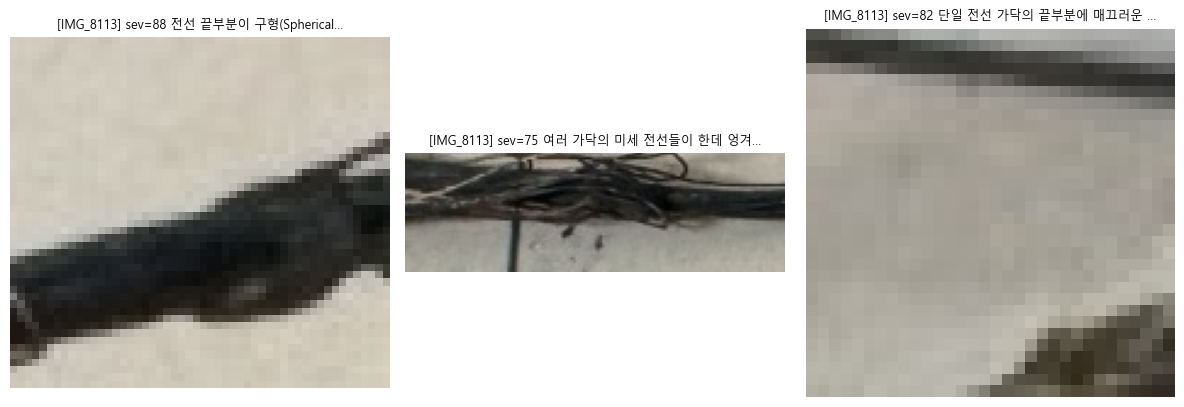

In [5]:
# 결과 출력 (좌표 기반 크롭 이미지만)
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 한글 제목 사용 시 기본 폰트(DejaVu Sans)에 한글 글리프가 없어 경고가 난다. 한글 폰트로 설정하면 해소된다.
import matplotlib.font_manager as fm
_prefer = ("Malgun Gothic", "Malgun Gothic", "NanumGothic", "AppleGothic", "Noto Sans CJK KR")
_available = {f.name for f in fm.fontManager.ttflist}
for _name in _prefer:
    if _name in _available:
        plt.rcParams["font.family"] = _name
        break

items = []  # (img_array, title) for each cropped hotspot
for _, row in df_results.iterrows():
    patch_path = row.get("patch_path")
    hotspots = row.get("hotspots") or []
    cat = row["Category"]
    if not patch_path or not os.path.exists(patch_path):
        items.append((None, f"[{cat}] 패치 없음"))
        continue
    if not hotspots:
        img = np.array(Image.open(patch_path))
        items.append((img, f"[{cat}] 탐지 없음"))
    else:
        for h in hotspots:
            box = h.get("box_2d")
            if not box:
                continue
            try:
                cropped_path = crop_roi_from_box(patch_path, box)
                img = np.array(Image.open(cropped_path))
                sc = h.get("severity_score", "")
                ev = (h.get("visual_evidence") or "")[:20]
                items.append((img, f"[{cat}] sev={sc} {ev}…"))
            except Exception:
                items.append((None, f"[{cat}] sev={h.get('severity_score','')} 크롭 실패"))

n = len(items)
logger.info(f"결과 시각화: 케이스 {len(df_results)}개, 표시 항목 {n}개")
cols = min(4, max(1, n))
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = np.atleast_2d(axes)
for i, (img, title) in enumerate(items):
    ax = axes[i // cols, i % cols]
    if img is not None:
        ax.imshow(img)
    else:
        ax.text(0.5, 0.5, "이미지 없음", ha="center", va="center", transform=ax.transAxes)
    ax.set_title(title, fontsize=9)
    ax.axis("off")
for j in range(n, rows * cols):
    axes[j // cols, j % cols].axis("off")
plt.tight_layout()
plt.show()